## Step 1: Load the Data
##  Load both CSVs into Pandas DataFrames

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# load the datasets
cust=pd.read_csv(r"D:\python\python datasets\Customer_Master_Data mini project_dataset.csv")
tran=pd.read_csv(r"D:\python\python datasets\Customer_Transactions mimi_project.csv")

##  shape, structure, and preview

In [3]:
#Display the first few rows of each dataset
cust.head()

,CustomerID,Name,Email,Gender,Age,City,MaritalStatus,NumChildren,JoinDate
0,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22
1,CUST10001,Divit Kohli,mkalita@sarin.com,Female,48,Kolkata,Married,0,2023-12-06
2,CUST10002,Kiara Behl,apteanay@hotmail.com,Male,75,Kolkata,Widowed,2,2023-08-23
3,CUST10003,Vaibhav Sankar,bseshadri@choudhry.info,Male,62,Pune,Divorced,2,2022-11-17
4,CUST10004,Shray D’Alia,bdhillon@toor-mall.com,Male,55,Delhi,Divorced,0,2022-12-04


In [4]:
cust.shape

(1000, 9)

In [5]:
cust.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     1000 non-null   object
 1   Name           1000 non-null   object
 2   Email          1000 non-null   object
 3   Gender         1000 non-null   object
 4   Age            1000 non-null   int64 
 5   City           1000 non-null   object
 6   MaritalStatus  1000 non-null   object
 7   NumChildren    1000 non-null   int64 
 8   JoinDate       1000 non-null   object
dtypes: int64(2), object(7)
memory usage: 70.4+ KB


In [6]:
tran.head()

,CustomerID,TransactionDate,TransactionAmount
0,CUST10771,7/31/23,2383.07
1,CUST10100,3/10/24,497.54
2,CUST10031,2/17/25,536.78
3,CUST10987,7/17/23,314.89
4,CUST10831,12/15/24,2543.19


In [7]:
tran.shape

(23050, 3)

In [8]:
tran.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23050 entries, 0 to 23049
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         23050 non-null  object 
 1   TransactionDate    23050 non-null  object 
 2   TransactionAmount  23050 non-null  float64
dtypes: float64(1), object(2)
memory usage: 540.4+ KB


## Data loading insight: 
The dataset holds transaction records for 1,000 customers, giving a robust foundation for customer behavior and revenue analysis

## Step 2: Clean the Data
## Convert JoinDate and TransactionDate columns to datetime

In [9]:
#convert date columns to datetime format 
tran['TransactionDate'] = pd.to_datetime(tran['TransactionDate'],errors='coerce')


C:\Users\user\AppData\Local\Temp\ipykernel_13544\1129678865.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  tran['TransactionDate'] = pd.to_datetime(tran['TransactionDate'],errors='coerce')


In [10]:
#convert date columns to datetime format
cust['JoinDate'] =  pd.to_datetime(cust['JoinDate'],errors='coerce')

In [11]:
#JoinDate column converted to datetime format
cust.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   CustomerID     1000 non-null   object        
 1   Name           1000 non-null   object        
 2   Email          1000 non-null   object        
 3   Gender         1000 non-null   object        
 4   Age            1000 non-null   int64         
 5   City           1000 non-null   object        
 6   MaritalStatus  1000 non-null   object        
 7   NumChildren    1000 non-null   int64         
 8   JoinDate       1000 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(6)
memory usage: 70.4+ KB


In [12]:
#TransactionDate coulmn converted to datetime format 
tran.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23050 entries, 0 to 23049
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   CustomerID         23050 non-null  object        
 1   TransactionDate    23050 non-null  datetime64[ns]
 2   TransactionAmount  23050 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 540.4+ KB


## Ensure no nulls or bad types

In [13]:
#Detection of missing values in the datasets 
cust.isnull().sum()

CustomerID       0
Name             0
Email            0
Gender           0
Age              0
City             0
MaritalStatus    0
NumChildren      0
JoinDate         0
dtype: int64

In [14]:
#Detection of missing values in the transaction dataset
tran.isnull().sum()

CustomerID           0
TransactionDate      0
TransactionAmount    0
dtype: int64

In [15]:
# Handling - Drop row with any missing values
tran.dropna(inplace=True)
cust.dropna(inplace=True)

## Validate uniqueness of CustomerID in master dataset


In [16]:
#Check for duplicate CustomerID in the customer dataset
cust['CustomerID'].duplicated().sum()

np.int64(0)

In [17]:
#Check for duplicate CustomerID in the transaction dataset
tran['CustomerID'].isin(cust['CustomerID']).all()

np.True_

In [18]:
#Check how many unique CustomerID present in transaction dataset 
tran['CustomerID'].unique()

array(['CUST10771', 'CUST10100', 'CUST10031', 'CUST10987', 'CUST10831',
       'CUST10404', 'CUST10488', 'CUST10988', 'CUST10657', 'CUST10007',
       'CUST10897', 'CUST10300', 'CUST10710', 'CUST10480', 'CUST10377',
       'CUST10184', 'CUST10214', 'CUST10892', 'CUST10561', 'CUST10879',
       'CUST10959', 'CUST10204', 'CUST10531', 'CUST10755', 'CUST10805',
       'CUST10547', 'CUST10231', 'CUST10141', 'CUST10443', 'CUST10715',
       'CUST10919', 'CUST10765', 'CUST10203', 'CUST10734', 'CUST10373',
       'CUST10503', 'CUST10233', 'CUST10049', 'CUST10251', 'CUST10850',
       'CUST10117', 'CUST10991', 'CUST10371', 'CUST10068', 'CUST10712',
       'CUST10043', 'CUST10217', 'CUST10442', 'CUST10339', 'CUST10754',
       'CUST10416', 'CUST10460', 'CUST10452', 'CUST10837', 'CUST10471',
       'CUST10901', 'CUST10672', 'CUST10609', 'CUST10763', 'CUST10631',
       'CUST10669', 'CUST10659', 'CUST10459', 'CUST10380', 'CUST10040',
       'CUST10208', 'CUST10932', 'CUST10697', 'CUST10265', 'CUST

## Ensure all transaction CustomerID

In [19]:
# Validate transaction CustomerIDs against customer master data
tran['CustomerID'].isin(cust['CustomerID']).value_counts()

CustomerID
True    23050
Name: count, dtype: int64

## Data Cleaning Insight:
 No major missing values, duplicate CustomerIDs, or invalid customer references were found after data cleaning. All 23,050 transaction records contain valid CustomerIDs that successfully match with the customer dataset, ensuring consistent, accurate, and reliable data for further analysis.

# Step 3: Merge if Needed
# ● Join Customer_Master_Data with Customer_Transactions on CustomerID (if
# data is required)

In [20]:
#Merge the transactio and Customer datasets on customerID
df=pd.merge(tran,cust,on=['CustomerID'],how="left")

In [21]:
df.head()

,CustomerID,TransactionDate,TransactionAmount,Name,Email,Gender,Age,City,MaritalStatus,NumChildren,JoinDate
0,CUST10771,2023-07-31,2383.07,Lakshay Dhillon,dharmajantara@gmail.com,Female,27,Ahmedabad,Widowed,3,2023-05-31
1,CUST10100,2024-03-10,497.54,Aniruddh Borah,jivikabhavsar@gmail.com,Female,53,Lucknow,Divorced,4,2022-01-08
2,CUST10031,2025-02-17,536.78,Ritvik Ahuja,jhaverifarhan@chandra.org,Male,40,Ahmedabad,Single,0,2023-12-03
3,CUST10987,2023-07-17,314.89,Jayan Wagle,ojas82@gmail.com,Not Disclosed,75,Bangalore,Widowed,4,2022-03-18
4,CUST10831,2024-12-15,2543.19,Ishita Agarwal,vbalay@yahoo.com,Not Disclosed,27,Jaipur,Divorced,4,2021-06-30


## Data Validation Insight: 
 All transaction CustomerIDs successfully matched with the customer master dataset, confirming complete data consistency.


## Step 4: Perform RFM Calculation
## ● Use groupby on CustomerID for:
## o max(TransactionDate) → Recency

In [22]:
df.groupby('CustomerID')['TransactionDate'].max()

CustomerID
CUST10000   2025-07-17
CUST10001   2025-06-25
CUST10002   2025-07-12
CUST10003   2025-05-10
CUST10004   2025-07-22
               ...    
CUST10995   2024-06-23
CUST10996   2025-07-15
CUST10997   2025-06-28
CUST10998   2025-03-26
CUST10999   2025-07-25
Name: TransactionDate, Length: 1000, dtype: datetime64[ns]

In [23]:
#Find the last transaction date for each customer
Lastdate=df.groupby('CustomerID')['TransactionDate'].max().reset_index().rename(columns={'TransactionDate':'LastTransactionDate'})

In [24]:
Lastdate

,CustomerID,LastTransactionDate
0,CUST10000,2025-07-17
1,CUST10001,2025-06-25
2,CUST10002,2025-07-12
3,CUST10003,2025-05-10
4,CUST10004,2025-07-22
...,...,...
995,CUST10995,2024-06-23
996,CUST10996,2025-07-15
997,CUST10997,2025-06-28
998,CUST10998,2025-03-26


In [25]:
#calculate the next day after the last transaction  date
from datetime import timedelta
today=df['TransactionDate'].max()+timedelta(days=1)

In [26]:
today

Timestamp('2025-07-30 00:00:00')

In [27]:
#Calculate recency for each customer
cust['Recency']=(today-Lastdate['LastTransactionDate']).dt.days
cust['Recency']

0       13
1       35
2       18
3       81
4        8
      ... 
995    402
996     15
997     32
998    126
999      5
Name: Recency, Length: 1000, dtype: int64

In [28]:
#Check for missing values in the Recency Column
cust['Recency'].isnull().sum()

np.int64(0)

##  count(TransactionDate) → Frequency

In [29]:
#Calculate Frequency for each Customer 
Frequency=df.groupby('CustomerID')['TransactionDate'].count().reset_index().rename(columns={'TransactionDate':'Frequency'})

In [30]:
Frequency

,CustomerID,Frequency
0,CUST10000,23
1,CUST10001,30
2,CUST10002,24
3,CUST10003,25
4,CUST10004,19
...,...,...
995,CUST10995,21
996,CUST10996,21
997,CUST10997,20
998,CUST10998,25


##  sum(TransactionAmount) → Monetary

In [31]:
#Calculate monetary value for each customer
Monetary=df.groupby('CustomerID')['TransactionAmount'].sum().reset_index().rename(columns={'TransactionAmount':'Monetary'})

In [32]:
Monetary

,CustomerID,Monetary
0,CUST10000,21265.49
1,CUST10001,28654.31
2,CUST10002,23884.03
3,CUST10003,24206.03
4,CUST10004,25565.30
...,...,...
995,CUST10995,24325.19
996,CUST10996,21809.11
997,CUST10997,21120.48
998,CUST10998,29494.56


In [33]:
df.head()

,CustomerID,TransactionDate,TransactionAmount,Name,Email,Gender,Age,City,MaritalStatus,NumChildren,JoinDate
0,CUST10771,2023-07-31,2383.07,Lakshay Dhillon,dharmajantara@gmail.com,Female,27,Ahmedabad,Widowed,3,2023-05-31
1,CUST10100,2024-03-10,497.54,Aniruddh Borah,jivikabhavsar@gmail.com,Female,53,Lucknow,Divorced,4,2022-01-08
2,CUST10031,2025-02-17,536.78,Ritvik Ahuja,jhaverifarhan@chandra.org,Male,40,Ahmedabad,Single,0,2023-12-03
3,CUST10987,2023-07-17,314.89,Jayan Wagle,ojas82@gmail.com,Not Disclosed,75,Bangalore,Widowed,4,2022-03-18
4,CUST10831,2024-12-15,2543.19,Ishita Agarwal,vbalay@yahoo.com,Not Disclosed,27,Jaipur,Divorced,4,2021-06-30


 ## RFM Analysis Insight:
 The RFM calculation highlighted diverse customer purchasing patterns, where some customers remained highly active with frequent and recent transactions, while others demonstrated lower engagement due to extended gaps in purchasing activity.

## Store result in a new DataFrame called df_rfm

In [34]:
# step by step Merge the recency,Frequency,Monetary dataframs on CustomerID
df_rfm=pd.merge(cust[['CustomerID','Recency']],Frequency,on="CustomerID",how="left")

In [35]:
df_rfm=pd.merge(df_rfm,Monetary,on="CustomerID",how="left")

In [36]:
df_rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,CUST10000,13,23,21265.49
1,CUST10001,35,30,28654.31
2,CUST10002,18,24,23884.03
3,CUST10003,81,25,24206.03
4,CUST10004,8,19,25565.30


## Step 5: Score RFM
## ● Use quantile-based scoring using pd.qcut() or rank() and cut()
## ● Create three new columns: R_Score, F_Score, M_Score

In [37]:
# Assign R, F, M scores based on quantiles
df_rfm['R_Score']=pd.qcut(df_rfm['Recency'],5,labels=[5,4,3,2,1])
df_rfm['F_Score']=pd.qcut(df_rfm['Frequency'],5,labels=[1,2,3,4,5])
df_rfm['M_Score']=pd.qcut(df_rfm['Monetary'],5,labels=[1,2,3,4,5])

In [38]:
df_rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,CUST10000,13,23,21265.49,4,3,2
1,CUST10001,35,30,28654.31,3,5,5
2,CUST10002,18,24,23884.03,4,3,3
3,CUST10003,81,25,24206.03,1,4,3
4,CUST10004,8,19,25565.30,5,1,4


# RFM Scoring Insight:
High RFM scores identified a small group of highly valuable customers contributing consistently through frequent and high-value purchases

## Step 6: Create Combined RFM Segment
##  Concatenate the R, F, M scores into a string like "555", "432", etc.

In [39]:
#Creat RFM Segment by concatenation R,F,M scores
df_rfm['Segment']=df_rfm['R_Score'].astype(str)+df_rfm['F_Score'].astype(str)+df_rfm['M_Score'].astype(str)

In [40]:
df_rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,Segment
0,CUST10000,13,23,21265.49,4,3,2,432
1,CUST10001,35,30,28654.31,3,5,5,355
2,CUST10002,18,24,23884.03,4,3,3,433
3,CUST10003,81,25,24206.03,1,4,3,143
4,CUST10004,8,19,25565.30,5,1,4,514


##  Step 7: Assign Segment Labels
##  ● Use business rules to define segment labels for selected score combinations
## ● Example:
o RFM 555 → Champion
o RFM 111 → Lost


In [41]:
#step by step Define segment labels based on RFM segments
df_rfm['Segment_Labels']='others'


In [42]:
df_rfm.loc[df_rfm['Segment']=='555','Segment_Labels']='Champions'

In [43]:
df_rfm.loc[df_rfm['Segment']=='111','Segment_Labels']='Lost'

In [44]:
df_rfm.loc[(df_rfm['Segment'].str[0]=='5')&(df_rfm['Segment']!='555'),'Segment_Labels']='Recent'

In [45]:
df_rfm.loc[(df_rfm['Segment'].str[1]=='5')&(df_rfm['Segment']!='555'),'Segment_Labels']='Frequent'

In [46]:
df_rfm.loc[(df_rfm['Segment'].str[2]=='5')&(df_rfm['Segment']!='555'),'Segment_Labels']='Big Spender'

In [47]:
#Analyze the distribution of customers access  segments
df_rfm['Segment_Labels'].value_counts()

Segment_Labels
others         543
Big Spender    165
Recent         160
Frequent        63
Champions       35
Lost            34
Name: count, dtype: int64

In [48]:
# Analyze the distribution  of customers  across segments
labels=df_rfm['Segment_Labels'].value_counts().values
index=df_rfm['Segment_Labels'].value_counts().index
index

Index(['others', 'Big Spender', 'Recent', 'Frequent', 'Champions', 'Lost'], dtype='object', name='Segment_Labels')

# RFM Segment Insight:
The largest customer group belonged to the “Others” segment (543 customers), indicating a broad mix of average purchasing behavior

## Step 8: Visualize
##  Count of customers in each segment

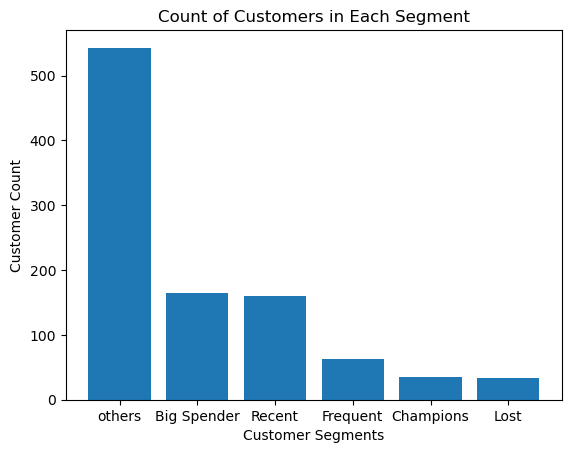

In [49]:
import matplotlib.pyplot as plt
segment_counts = df_rfm['Segment_Labels'].value_counts()
plt.bar(segment_counts.index, segment_counts.values)
plt.xlabel('Customer Segments')
plt.ylabel('Customer Count')
plt.title('Count of Customers in Each Segment')
plt.show()

## Big Spender Insight :
The “Big Spender” segment contains 165 customers and contributes 22.3% of total revenue, making it one of the most valuable customer groups despite its relatively smaller size.
## Champion Segment Insight
Only 35 customers were classified as “Champions,” but they generated high transaction values with very recent purchasing activity. This segment represents the most valuable and loyal customers of the business.
## Lost Customer Insight
A total of 34 customers were classified as “Lost,” indicating low purchase frequency, low spending behavior, and long periods of inactivity. These customers may require re-engagement strategies to reduce churn.
## Recent Customer Insight
Around 160 customers were categorized as “Recent,” showing that many customers made purchases recently. This indicates strong current engagement and potential opportunities for retention and repeat purchases.


##  ● Revenue contribution per segment

<Axes: ylabel='Monetary'>

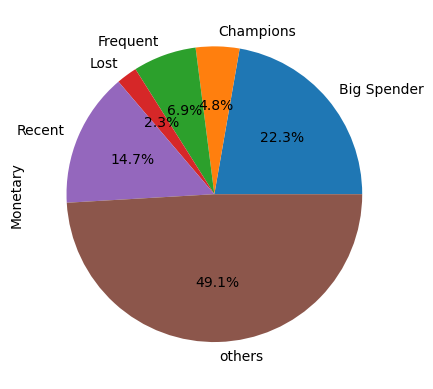

In [50]:
df_rfm.groupby('Segment_Labels')['Monetary'].sum().plot(kind='pie',autopct="%0.1f%%")

 Big Spender customers account for 22.3% of total revenue, the second-highest among all segments, despite containing only 165 customers. This indicates that these customers have high purchasing power and contribute significantly to business revenue.

## ● Recency vs Monetary scatter plot colored by segment

In [51]:
df_rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   CustomerID      1000 non-null   object  
 1   Recency         1000 non-null   int64   
 2   Frequency       1000 non-null   int64   
 3   Monetary        1000 non-null   float64 
 4   R_Score         1000 non-null   category
 5   F_Score         1000 non-null   category
 6   M_Score         1000 non-null   category
 7   Segment         1000 non-null   object  
 8   Segment_Labels  1000 non-null   object  
dtypes: category(3), float64(1), int64(2), object(3)
memory usage: 50.6+ KB


In [52]:
df_rfm['Segment_Labels'].value_counts()

Segment_Labels
others         543
Big Spender    165
Recent         160
Frequent        63
Champions       35
Lost            34
Name: count, dtype: int64

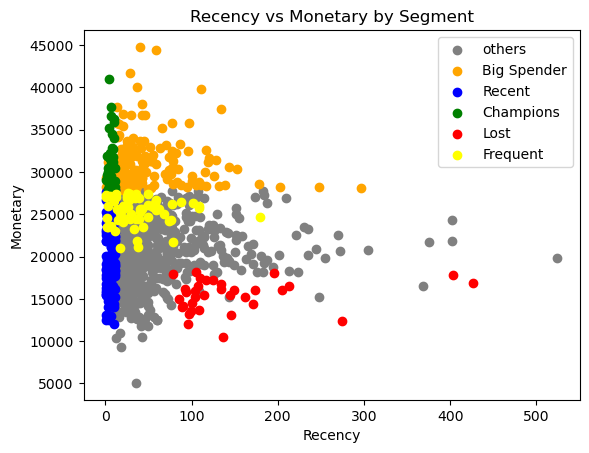

In [53]:
palette = {
    'others': 'gray',
    'Big Spender': 'orange',
    'Recent': 'blue',
    'Frequent': 'yellow',
    'Lost': 'red',
    'Champions': 'green'
}

plt.figure()

for segment in df_rfm['Segment_Labels'].unique():

    subset = df_rfm[df_rfm['Segment_Labels'] == segment]

    plt.scatter(
        subset['Recency'],
        subset['Monetary'],
        label=segment,
        color=palette.get(segment)
    )

plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.title("Recency vs Monetary by Segment")
plt.legend()
plt.show()

The scatter plot shows that customers with lower recency values (customers who purchased recently) tend to have higher monetary spending. A large concentration of points is visible between recency 0–30 days, indicating that recently active customers make frequent and higher-value purchases.
On the other hand, customers with very high recency values are fewer in number and generally show lower spending behavior. This suggests a negative relationship between recency and monetary value — as recency increases, customer spending tends to decrease.
The segmented scatter plot further shows that “Big Spender” and “Champion” customers are mostly concentrated in the low-recency and high-monetary region, whereas “Lost” customers are spread across higher recency values with comparatively lower spending.

## Pareto Analysis: Show how top 20% customers contribute to 80% revenue

In [54]:
df=df_rfm[['CustomerID','Monetary']]

In [55]:
df=df.sort_values(by='Monetary',ascending=False)

In [56]:
df['Cumulative_Revenue']=df['Monetary'].cumsum()

In [57]:
df['Revenue_percent']=df['Cumulative_Revenue']/df['Monetary'].sum()*100

In [58]:
df=df.reset_index(drop=True)

In [59]:
df['Customer_percent']=(df.index+1)/len(df)*100

In [60]:
df[df['Customer_percent']<=20].tail(1)

,CustomerID,Monetary,Cumulative_Revenue,Revenue_percent,Customer_percent
199,CUST10338,27838.98,6231163.35,27.029495,20.0


Based on the Pareto Principle, the top 20% of customers should contribute 80% of the revenue. However, this condition is not satisfied in the dataset. Hence, the data does not satisfy the Pareto rule.

In [61]:
df[df['Customer_percent']<=50].tail(1)

,CustomerID,Monetary,Cumulative_Revenue,Revenue_percent,Customer_percent
499,CUST10516,22987.87,13785960.82,59.800639,50.0


In [62]:
df[df['Customer_percent']<=70].tail(1)

,CustomerID,Monetary,Cumulative_Revenue,Revenue_percent,Customer_percent
699,CUST10191,19792.84,18055448.07,78.32079,70.0


In [63]:
df[df['Customer_percent']<=80].tail(1)

,CustomerID,Monetary,Cumulative_Revenue,Revenue_percent,Customer_percent
799,CUST10289,18164.57,19947157.43,86.526633,80.0


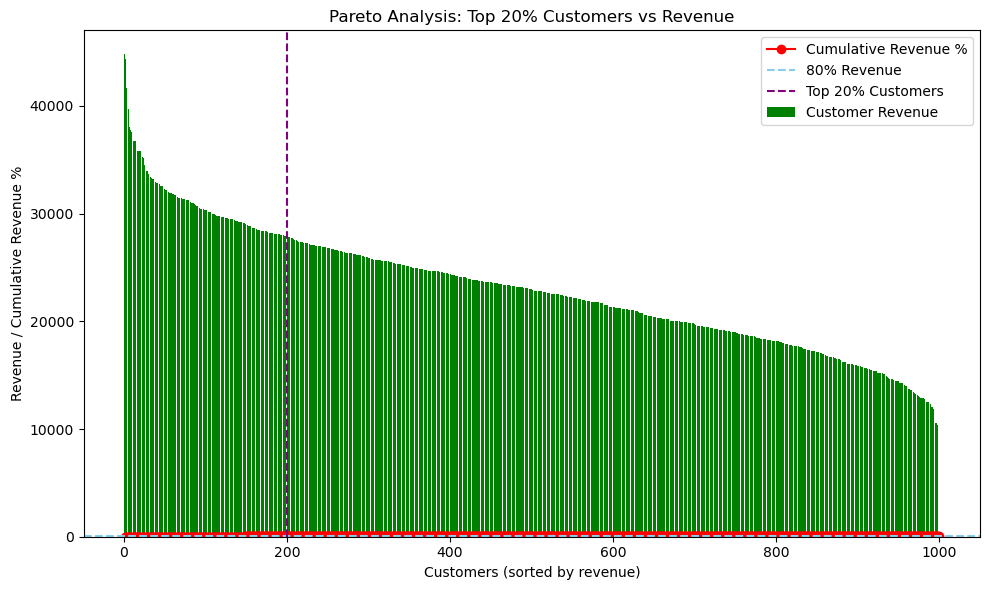

In [71]:
plt.figure(figsize=(10, 6))
plt.bar(df.index + 1, df['Monetary'], color='green', label='Customer Revenue')
plt.plot(df.index + 1,df['Revenue_percent'], color='red', marker='o', label='Cumulative Revenue %')

# Reference lines
plt.axhline(80, color='skyblue', linestyle='--', label='80% Revenue')
plt.axvline(len(df) * 0.2, color='purple', linestyle='--', label='Top 20% Customers')

plt.title('Pareto Analysis: Top 20% Customers vs Revenue')
plt.xlabel('Customers (sorted by revenue)')
plt.ylabel('Revenue / Cumulative Revenue %')
plt.legend()
plt.tight_layout()
plt.show()

The graph indicates that the dataset does not follow the Pareto (80/20) rule, as the top 20% of customers do not contribute 80% of the total revenue. Instead, revenue is distributed more evenly across customers, showing that the business depends on a broader customer base rather than a small group of high-revenue customers.